# 하이퍼파라미터 튜닝 · Grid vs Random · SHAP

- **데이터**: Seaborn **`diamonds`**
- **논문**: Bergstra & Bengio (2012) · Lundberg & Lee (2017)

- https://shap.readthedocs.io/en/latest/
- https://jmlr.org/papers/v13/bergstra12a.html


---
## 0. 환경 설정


### 문제 1. 라이브러리



In [2]:
!pip install -q shap

In [13]:
import sys
import time

# 1. OS 환경 확인 및 한글 폰트(나눔폰트) 설치
# macOS('darwin')가 아닌 리눅스/우분투 환경(예: Google Colab)일 때만 시스템 폰트를 설치합니다.
if sys.platform != 'darwin':
    # -qq 옵션과 2>/dev/null을 사용하여 설치 로그를 숨기고 조용히 설치합니다.
    !sudo apt-get install -y -qq fonts-nanum 2>/dev/null
    # 폰트 캐시를 갱신하여 시스템에 반영합니다.
    !fc-cache -fv 2>/dev/null
    # matplotlib의 구형 폰트 캐시를 삭제하여 새로 설치된 폰트를 인식하게 합니다.
    !rm -rf ~/.cache/matplotlib 2>/dev/null

# 2. 필수 데이터 분석 및 머신러닝 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import shap  # 모델 설명을 위한 SHAP 라이브러리
from scipy.stats import loguniform  # 무작위 탐색(RandomizedSearch)용 확률 분포
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')  # 버전 변화 등으로 인한 단순 경고 문구 숨기기

# 3. 폰트 매니저에 나눔 폰트 명시적 등록
# 리눅스 경로와 macOS 경로를 모두 고려하여 시스템에 폰트를 추가합니다.
for d in ['/usr/share/fonts/truetype/nanum', '/Library/Fonts']:
    for ff in fm.findSystemFonts(fontpaths=[d]):
        fm.fontManager.addfont(ff)

# 4. Matplotlib 및 Seaborn 글로벌 시각화 설정
# 마이너스 기호(-) 깨짐 방지 및 나눔바른고딕을 기본 폰트로 지정합니다.
plt.rcParams.update({'font.family': 'NanumBarunGothic', 'axes.unicode_minus': False, 'figure.dpi': 110})
sns.set_theme(style='whitegrid', font='NanumBarunGothic', rc={'axes.unicode_minus': False})

# 5. 실험의 재현성을 위한 난수 고정 (Random Seed)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped directory detected
/var/cache/fontconfig: cleaning cache directory
/root/.cache/fontconfig: not cleaning non-existent cache directory
/root/.fontconfig: not cleaning non-existent cache director

### 문제 2. diamonds `.loc` 파생 특성
- price 예측 feature engineering.


In [4]:
# 1. 원본 데이터 복사
diamonds = sns.load_dataset('diamonds')
dia = diamonds.copy()

# 2. 고급 파생 변수(Feature Engineering) 생성
# 파생 변수 1: 캐럿과 깊이를 곱한 부피 대용 지표
dia.loc[:, 'volume_proxy'] = dia.loc[:, 'carat'] * dia.loc[:, 'depth']

# 파생 변수 2: 가로 폭(table) 대비 깊이(depth)의 비율
# 분모가 0인 경우를 NaN으로 대체하여 ZeroDivisionError를 방지하는 정석적인 패턴입니다.
dia.loc[:, 'ratio_table'] = dia.loc[:, 'table'] / dia.loc[:, 'depth'].replace(0, np.nan)

# 3. 데이터 정제 (결측치 제거)
# 생성한 파생 변수를 포함해 모델에 사용할 특징(Feature) 컬럼 리스트 정의
feat_cols = ['carat', 'depth', 'table', 'volume_proxy', 'ratio_table']
# 지정된 5개 컬럼 중 하나라도 결측치(NaN)가 있는 행을 모두 제거하고, price 컬럼과 함께 추출합니다.
dia = dia.loc[dia[feat_cols].notnull().all(axis=1), feat_cols + ['price']]

# 4. 입력(X) 및 타깃(y) 넘파이 배열로 변환
X = dia.loc[:, feat_cols].values
y = dia.loc[:, 'price'].values

# 5. 데이터 분할
# 전체 데이터의 20%(test_size=0.2)를 최종 평가용 테스트셋으로 안전하게 분리합니다.
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

# 6. 학습 데이터 크기 출력
# 준비된 최종 독립변수 특징의 개수(5개)와 데이터의 개수가 올바르게 출력되는지 확인합니다.
print('train', X_tr.shape)

train (43152, 5)


In [17]:
diamonds.head(1)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43


In [16]:
dia.head(1)

,carat,depth,table,volume_proxy,ratio_table,price
0,0.23,61.5,55.0,14.145,0.894309,326


---
## 1. Grid vs Random Search


### 문제 3. Bergstra & Bengio (2012)

**[개념 및 논문 리뷰]**
- **논문**: Bergstra, J., & Bengio, Y. (2012). *Random Search for Hyper-Parameter Optimization*. JMLR, 13, 281–305.

- Grid는 **모든 조합** — 저차원 격자에 낭비. Random은 **중요 파라미터** 공간을 더 **efficiently** 탐색.


In [18]:
# 1. 전처리 + 모델 파이프라인 생성
# 데이터 누수 없이 폴드별로 독립적인 스케일링을 적용하기 위해 파이프라인을 선언합니다.
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge())
])

# 2. Ridge 모델의 규제 파이프라인 파라미터(alpha) 후보 생성
# 10^-3 (0.001)부터 10^3 (1000) 사이를 로그 스케일 기준으로 균등하게 15개 구간으로 쪼갭니다.
# 릿지 회귀의 가중치 제한 크기를 결정하는 핵심 하이퍼파라미터입니다.
alphas = np.logspace(-3, 3, 15)

# 3. 탐색할 Grid alpha 후보의 개수 확인
print('Grid alpha 후보:', len(alphas))

Grid alpha 후보: 15


### 문제 4. GridSearchCV — Ridge

- 15 alpha 전수 탐색.


In [19]:
import time

# 1. 파이프라인 및 하이퍼파라미터 그리드 정의
pipe_ridge = Pipeline([('scaler', StandardScaler()), ('model', Ridge())])
# 파이프라인 내부의 model(Ridge)의 alpha 값을 바꾸기 위해 'model__alpha' 형식을 취합니다.
param_grid = {'model__alpha': np.logspace(-3, 3, 15)}

# 2. 그리드 서치 수행 및 시간 측정 시작
t0 = time.perf_counter()

# cv=3이므로 15개 후보군에 대해 총 45번의 학습/검증이 병렬(n_jobs=-1)로 실행됩니다.
grid = GridSearchCV(pipe_ridge, param_grid, cv=3,
                    scoring='neg_root_mean_squared_error', n_jobs=-1)
grid.fit(X_tr, y_tr)

# 소요 시간 계산
grid_time = time.perf_counter() - t0

# 3. 최적의 결과 및 정보 출력
# 45번의 실험 중 가장 검증 RMSE 성능이 낮았던(좋았던) 최적의 alpha 값을 출력합니다.
print('best alpha:', grid.best_params_['model__alpha'])
# 최적 alpha 일 때의 최고 평가지표(음수 RMSE)를 다시 양수 RMSE 점수로 변환하여 출력합니다.
print('CV RMSE:', -grid.best_score_.round(2))
# 병렬 연산 처리를 거친 전체 탐색 소요 시간을 초 단위로 확인합니다.
print('time:', round(grid_time, 2), 's')

best alpha: 0.0517947467923121
CV RMSE: 1508.91
time: 2.95 s


### 문제 5. RandomizedSearchCV — ElasticNet

- alpha log-uniform + l1_ratio.


In [20]:
# 1. ElasticNet 기반의 파이프라인 구축
# ElasticNet은 수렴 속도가 느릴 수 있으므로 max_iter=5000으로 충분히 높여 안정성을 확보했습니다.
pipe_en = Pipeline([
    ('scaler', StandardScaler()),
    ('model', ElasticNet(max_iter=5000, random_state=RANDOM_STATE))
])

# 2. 무작위 탐색을 위한 확률 분포 및 후보 지정
# model__alpha: 10^-3부터 10^3까지 로그 스케일상에서 균등한 확률로 연속적인 실수 값을 샘플링합니다.
# model__l1_ratio: L1(Lasso) 규제의 비율을 지정합니다. (0에 가까우면 Ridge, 1에 가까우면 Lasso 형태)
param_dist = {
    'model__alpha': loguniform(1e-3, 1e3),
    'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
}

# 3. 랜덤 서치(RandomizedSearchCV) 수행 및 시간 측정 시작
t0 = time.perf_counter()

# n_iter=15이므로 무작위로 추출한 15개 하이퍼파라미터 조합에 대해 cv=3(총 45번 학습/검증)을 실행합니다.
rand_search = RandomizedSearchCV(
    pipe_en, param_dist, n_iter=15, cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=RANDOM_STATE, n_jobs=-1,
)
rand_search.fit(X_tr, y_tr)

# 소요 시간 계산
rand_time = time.perf_counter() - t0

# 4. 결과 출력
# 15개 랜덤 조합 중 교차 검증 성능이 가장 좋았던 alpha와 l1_ratio 조합을 출력합니다.
print('best:', rand_search.best_params_)
# 최적 조합의 평가지표(음수 RMSE)를 다시 양수 RMSE 점수로 변환하여 출력합니다.
print('CV RMSE:', -rand_search.best_score_.round(2))
# 전체 무작위 탐색에 소요된 시간을 확인합니다.
print('time:', round(rand_time, 2), 's')

best: {'model__alpha': np.float64(0.0019054343023324116), 'model__l1_ratio': 0.7}
CV RMSE: 1514.67
time: 12.98 s


### 문제 6. Grid vs Random — 시간·RMSE Bar Chart

- Ridge, n_iter=15.


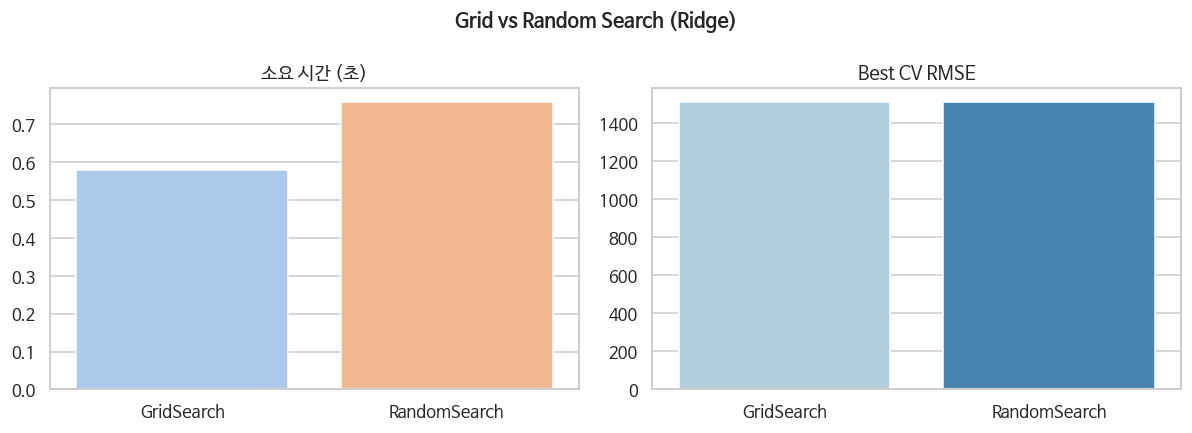

In [21]:
# 공통 파이프라인 및 탐색용 기본 세팅
pipe_r = Pipeline([('scaler', StandardScaler()), ('model', Ridge())])

# [실험 1: Grid Search]
# 지정된 고정 격자 포인트 15개를 순차적으로 모두 탐색합니다.
pg = {'model__alpha': np.logspace(-3, 3, 15)}
t0 = time.perf_counter()
g15 = GridSearchCV(pipe_r, pg, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1).fit(X_tr, y_tr)
t_grid = time.perf_counter() - t0

# [실험 2: Random Search]
# 지정된 연속 분포 범위(10^-3 ~ 10^3) 내에서 무작위로 15개의 점을 추출하여 탐색합니다.
t0 = time.perf_counter()
r15 = RandomizedSearchCV(
    pipe_r, {'model__alpha': loguniform(1e-3, 1e3)},
    n_iter=15, cv=3, scoring='neg_root_mean_squared_error',
    random_state=RANDOM_STATE, n_jobs=-1,
).fit(X_tr, y_tr)
t_rand = time.perf_counter() - t0

# [3. 시각화 피드백 배치 - 1행 2열 서브플롯]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Grid vs Random Search (Ridge)', fontsize=13, fontweight='bold')

# 왼쪽 그래프: 두 탐색 알고리즘의 소요 시간 비교 (초 단위)
sns.barplot(x=['GridSearch', 'RandomSearch'], y=[t_grid, t_rand], ax=axes[0], palette='pastel')
axes[0].set_title('소요 시간 (초)')

# 오른쪽 그래프: 두 탐색 알고리즘이 찾아낸 최적의 교차 검증 RMSE 비교 (클수록 음수 스코어가 작으므로 마이너스 처리)
sns.barplot(x=['GridSearch', 'RandomSearch'],
            y=[-g15.best_score_, -r15.best_score_], ax=axes[1], palette='Blues')
axes[1].set_title('Best CV RMSE')

plt.tight_layout()
plt.show()

### 문제 7. Test set 최종 평가

- 튜닝 모델 hold-out.


In [9]:
# 1. 최적의 하이퍼파라미터로 학습된 최종 모델 추출
# 앞선 탐색(rand_search)에서 교차 검증 점수가 가장 높았던 파이프라인 객체를 그대로 가져옵니다.
best_model = rand_search.best_estimator_

# 2. 독립된 테스트 데이터셋 예측
# 테스트셋 전처리(scaler.transform)와 예측(model.predict)이 파이프라인 내부에서 누수 없이 안전하게 실행됩니다.
y_pred = best_model.predict(X_te)

# 3. 최종 평가지표 계산 및 출력
# Test RMSE: 실제 다이아몬드 가격과 모델 예측 가격 간의 평균적인 오차 금액(달러)을 확인합니다.
print('Test RMSE:', np.sqrt(mean_squared_error(y_te, y_pred)).round(2))

# Test R² (결정계수): 모델이 다이아몬드 가격 변동성을 몇 %나 설명하는지 나타냅니다. (1.0에 가까울수록 완벽한 모델)
print('Test R²  :', np.round(r2_score(y_te, y_pred), 2))

Test RMSE: 1518.21
Test R²  : 0.86


---
## 2. 계수 한계 · SHAP


### 문제 8. Ridge 계수 해석 한계

- **한계**: 상관 특성 불안정, 스케일 의존, **로컬** 설명 불가 → SHAP.


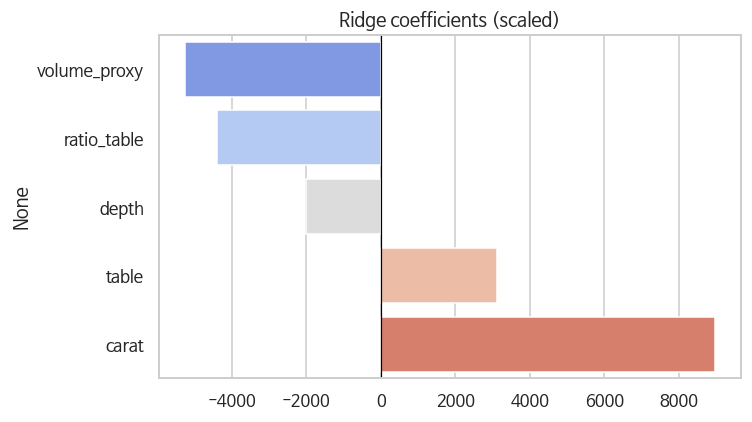

In [10]:
# 1. 랜덤 서치에서 찾은 최적의 하이퍼파라미터 딕셔너리 추출
bp = rand_search.best_params_

# 2. 계수 추출을 위한 임시 스케일러 및 Ridge 모델 학습
# 가중치(coef_)를 직접 뽑아내기 위해 파이프라인 대신 명시적으로 객체를 만들어 학습시킵니다.
scaler_tmp = StandardScaler().fit(X_tr)
# 최적 탐색 결과로 얻은 'model__alpha' 값을 규제 강도로 지정합니다.
ridge_tmp = Ridge(alpha=bp['model__alpha']).fit(scaler_tmp.transform(X_tr), y_tr)

# 3. 변수명과 가중치를 매핑하여 정렬
# 정렬을 해두면 시각화했을 때 어떤 변수가 가장 긍정적/부정적 영향을 주었는지 한눈에 파악하기 좋습니다.
coef_s = pd.Series(ridge_tmp.coef_, index=feat_cols).sort_values()

# 4. 가중치 바 플롯(Bar Plot) 시각화
fig, ax = plt.subplots(figsize=(7, 4))
# 가중치 크기에 따라 'coolwarm' 팔레트(음수는 파란색 계열, 양수는 빨간색 계열)를 적용합니다.
sns.barplot(x=coef_s.values, y=coef_s.index, ax=ax, palette='coolwarm')

# 그래프 스타일 가독성 높이기
ax.set_title('Ridge coefficients (scaled)')
ax.axvline(0, color='black', lw=0.8) # 영향력이 0인 지점에 세로 기준선 추가
plt.tight_layout()
plt.show()


### 문제 9. SHAP summary_plot — Lundberg & Lee (2017)

- **논문**: Lundberg & Lee (2017) NeurIPS. Shapley → $\sum_j \phi_j = f(x)-E[f]$.


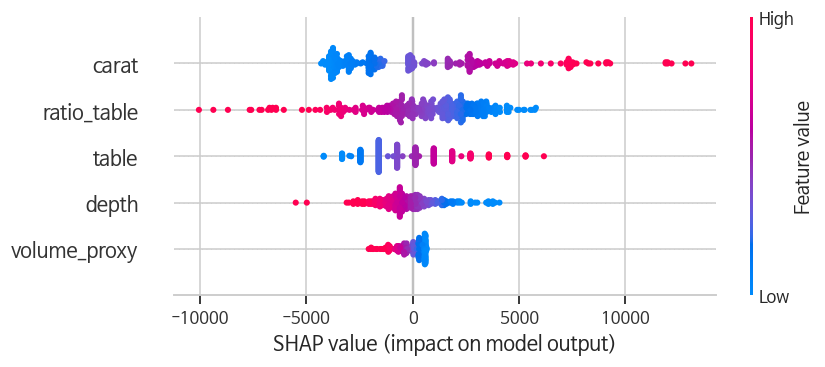

In [22]:
# 1. SHAP 분석을 위한 샘플 데이터프레임 구성
# 계산 속도와 가독성을 위해 300개의 샘플만 추출하고, 넘파이 배열에 컬럼명을 다시 입혀 줍니다.
X_sample = pd.DataFrame(X_tr[:300], columns=feat_cols)

# 2. SHAP 커널 및 설명자(Explainer) 정의
# 최적의 파이프라인 모델의 예측 함수(predict)와 기준이 될 샘플 데이터를 전달합니다.
explainer = shap.Explainer(best_model.predict, X_sample)

# 3. 샘플 데이터에 대한 SHAP 값(기여도) 계산
# 각 행, 각 변수마다 모델 예측치를 얼마나 높였거나 낮췄는지에 대한 물리적 수치(Shapley value)가 계산됩니다.
shap_values = explainer(X_sample)

# 4. SHAP 요약 플롯(Summary Plot) 시각화
# 변수별 중요도(글로벌)와 기여 방향(로컬)을 동시에 보여주는 SHAP의 핵심 시각화 도구입니다.
# show=False로 설정하여 matplotlib의 tight_layout 등 추가 가독성 설정을 적용할 수 있게 합니다.
shap.summary_plot(shap_values.values, X_sample, feature_names=feat_cols, show=False)

# 5. 레이아웃 마감 및 출력
plt.tight_layout()
plt.show()

### SHAP 결과 핵심 요약

- **`carat` (1위, 압도적 영향력):** 다이아몬드 가격을 결정하는 가장 지배적인 변수입니다. 값이 커질수록(빨간색) 가격이 우상향($+$)하는 가장 직관적인 패턴을 보입니다.
- **파생 변수 `ratio_table` (2위, 높은 기여도):** 가로 폭 대비 깊이의 비율 지표로, 캐럿 다음으로 모델 예측에 큰 영향을 미쳤습니다. 다이아몬드의 세부 비율(Cut)을 대변하는 유용한 피처임이 증명되었습니다.
- **`table` (3위, 정적 상관):** 다이아몬드 윗면 넓이로, 값이 클수록 가격을 높게 예측하는 경향을 보입니다.
- **부호 뒤집힘 및 다중공선성 현상 (`ratio_table`, `depth`, `volume_proxy`):**
  + 변수의 실제 값이 클 때(빨간색) 오히려 가격을 깎아내리는(왼쪽, $-$) 역방향 기여가 관찰됩니다.
- 이는 파생 변수 생성 과정에서 기존 변수들과 정보가 심하게 겹치면서, 선형 규제 모델(Ridge/ElasticNet)이 가중치 균형을 맞추기 위해 부호를 반대로 조율했기 때문입니다.

- `volume_proxy`는 `carat`과 정보가 너무 중복되어 중요도도 꼴찌이며 다중공선성만 유발하고 있습니다.
  + 모델의 안정성과 해석력을 높이기 위해 **다음 버전에서는 `volume_proxy` 변수를 제거하고 재학습**하는 것을 권장합니다.

### 문제 10. SHAP waterfall_plot — 로컬 1건

- 최고가 샘플 price 분해.


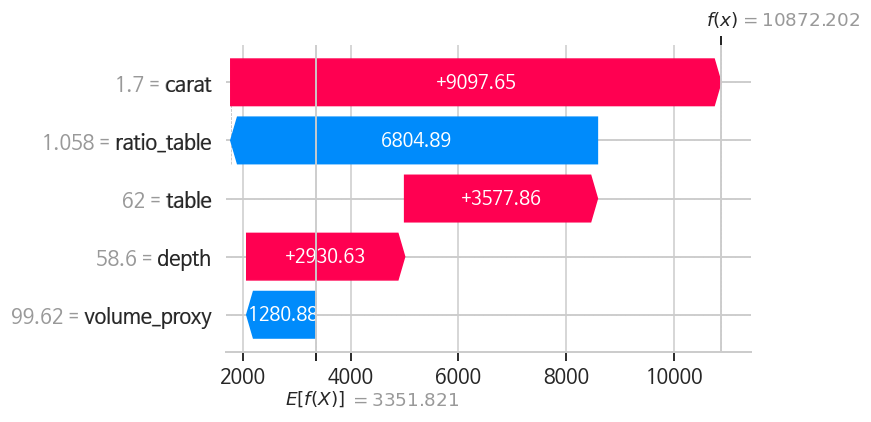

actual: 18,342, pred: 10,872


In [12]:
# 1. 300개 샘플 중 실제 가격(y_tr)이 가장 높은 데이터의 인덱스 추출
idx = int(np.argmax(y_tr[:300]))

# 2. 해당 인덱스의 입력 특성(X)을 데이터프레임 형태로 한 행만 추출
single = X_sample.iloc[[idx]]

# 3. 이 단 하나의 다이아몬드에 대한 SHAP 값 계산
sv1 = explainer(single)

# 4. SHAP 폭포수 플롯(Waterfall Plot) 시각화
# 베이스라인(평균 가격)에서 시작해 각 변수들이 가격을 얼마나 더하고 뺐는지 누적 과정을 보여줍니다.
shap.plots.waterfall(sv1[0], show=False)

# 5. 레이아웃 조절 및 그래프 출력
plt.tight_layout()
plt.show()

# 6. 실제 가격과 모델의 예측 가격을 쉼표(,)가 포함된 금액 포맷으로 비교 출력
print(f'actual: {y_tr[idx]:,.0f}, pred: {best_model.predict(single.values)[0]:,.0f}')

### SHAP Waterfall Plot 결과 해석 가이드

그래프가 화면에 나타나면 아래 흐름을 따라 읽으시면 됩니다.

- **시작점 $E[f(X)]_{\text{:}}$** 플롯의 맨 아래 혹은 기준선에 표시되는 값으로, 300개 샘플 다이아몬드의 **평균 예측 가격**입니다.
- **도착점 $f(x)_{\text{:}}$** 플롯의 맨 위에 표시되는 값으로, 모델이 이 가장 비싼 다이아몬드에 내린 **최종 예측 가격**입니다. (`pred` 출력값과 일치)
- **화살표의 방향과 색상:**
  + **빨간색 화살표 ($+$) :** 평균 가격에서 가격을 이만큼 **상승**시킨 요인입니다. 가장 비싼 다이아몬드인 만큼 `carat` 변수가 거대한 빨간색 화살표를 그리며 가격을 위로 견인했을 것입니다.
  + **파란색 화살표 ($-$) :** 반대로 가격을 이만큼 **감소**시킨 요인입니다. 앞서 Summary Plot에서 확인했듯 다중공선성으로 인해 부호가 뒤집힌 `ratio_table`이나 `volume_proxy`가 파란색 화살표로 작동하여 가격을 일부 깎아내리는 모습을 볼 수 있습니다.


- **실제값 표시:** 각 변수 이름 옆에 `carat = 1.7`과 같이 이 다이아몬드가 가진 실제 물리적 수치가 함께 표현되므로, "아, 캐럿이 이 정도로 크니까 가격이 이만큼 폭등했구나!"를 직관적으로 설명할 수 있습니다.